In [ ]:
# Machine Learning-based Predictive Derisking for Dairy Investment in Nakasongola District (Uganda)

1. Proper use of classes, objects, and methods.
2. Key OOP principles:
   - Encapsulation: state + behaviour inside classes
   - Inheritance & polymorphism: shared BaseRiskModel with multiple model types
   - Abstraction: abstract base class hides model details behind common interface
3. Modularity & reusability:
   - Clear separation: configuration, data sources, feature builder, models, reports, UI.
4. System functionality:
   - Loads local panel data
   - Scrapes external Ugandan data sources
   - Trains ML models
   - Evaluates risk & generates feasibility report
5. External libraries:
   - pandas, numpy, scikit-learn, requests, BeautifulSoup

In [35]:
# Imports and configuration

import requests
import pandas as pd
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any
from datetime import datetime

import matplotlib.pyplot as plt  # for plots in later cell

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

import abc  # for abstract base model classes


@dataclass
class ProjectConfig:
    """Holds settings for the project (location + time range)."""
    latitude: float = 1.32
    longitude: float = 32.45
    start_date: str = "2014-01-01"
    end_date: str = "2024-12-31"


config = ProjectConfig()
print("[CONFIG] Loaded project configuration:")
print(config)

[CONFIG] Loaded project configuration:
ProjectConfig(latitude=1.32, longitude=32.45, start_date='2014-01-01', end_date='2024-12-31')


In [36]:
# Climate scrapper 

class ClimateScraper:
    """
    Scrapes daily mean temperature and rainfall for Nakasongola
    and aggregates to a complete monthly climate panel.
    """

    def __init__(self, config: ProjectConfig):
        self.config = config
        print("[INIT] ClimateScraper ready with config:", self.config)

    def fetch_daily_data(self) -> pd.DataFrame:
        """Fetch daily climate data from Open-Meteo ERA5."""
        base_url = "https://archive-api.open-meteo.com/v1/era5"
        params = {
            "latitude": self.config.latitude,
            "longitude": self.config.longitude,
            "start_date": self.config.start_date,
            "end_date": self.config.end_date,
            "daily": "temperature_2m_mean,precipitation_sum",
            "timezone": "Africa/Nairobi",
        }

        print("[STEP] Requesting daily climate data from Open-Meteo...")
        resp = requests.get(base_url, params=params, timeout=120)
        resp.raise_for_status()
        data = resp.json()

        df = pd.DataFrame({
            "date": data["daily"]["time"],
            "temp_c_mean": data["daily"]["temperature_2m_mean"],
            "rain_mm": data["daily"]["precipitation_sum"],
        })
        df["date"] = pd.to_datetime(df["date"])

        print("[OUTPUT] Daily climate data fetched. Shape:", df.shape)
        print(df.head())
        return df

    def to_monthly_panel(self, df_daily: pd.DataFrame) -> pd.DataFrame:
        """
        Aggregate daily data to monthly and ensure every month
        from Jan 2014 to Dec 2024 is present.
        """
        print("[STEP] Aggregating daily → monthly climate data...")
        df = df_daily.copy()
        df["year"] = df["date"].dt.year
        df["month"] = df["date"].dt.month

        monthly = df.groupby(["year", "month"]).agg(
            temp_c_mean=("temp_c_mean", "mean"),
            rain_mm_total=("rain_mm", "sum"),
        ).reset_index()

        # Build a complete monthly index from start_date to end_date
        full_months = pd.period_range(self.config.start_date, self.config.end_date, freq="M")
        full = pd.DataFrame({
            "year": full_months.year,
            "month": full_months.month,
        })

        # Merge with computed monthly values
        monthly_full = full.merge(monthly, on=["year", "month"], how="left")

        # Handle any missing values
        monthly_full["temp_c_mean"] = (
            monthly_full["temp_c_mean"]
            .interpolate()
            .fillna(method="bfill")
            .fillna(method="ffill")
        )
        monthly_full["rain_mm_total"] = (
            monthly_full["rain_mm_total"]
            .fillna(0)
        )

        print("[OUTPUT] Monthly climate panel ready. Shape:", monthly_full.shape)
        print(monthly_full.head())
        return monthly_full

print("[CONFIRM] ClimateScraper class defined.")

[CONFIRM] ClimateScraper class defined.


In [37]:
# run climate scraping

scraper = ClimateScraper(config)

daily_df = scraper.fetch_daily_data()
monthly_df = scraper.to_monthly_panel(daily_df)

print("\n[SUMMARY] Daily climate rows:", len(daily_df))
print("[SUMMARY] Monthly climate rows (expected 11 years * 12 months = 132):", len(monthly_df))

[INIT] ClimateScraper ready with config: ProjectConfig(latitude=1.32, longitude=32.45, start_date='2014-01-01', end_date='2024-12-31')
[STEP] Requesting daily climate data from Open-Meteo...
[OUTPUT] Daily climate data fetched. Shape: (4018, 3)
        date  temp_c_mean  rain_mm
0 2014-01-01         22.6      5.0
1 2014-01-02         23.3      0.1
2 2014-01-03         23.9      0.0
3 2014-01-04         24.1      0.0
4 2014-01-05         24.5      0.0
[STEP] Aggregating daily → monthly climate data...
[OUTPUT] Monthly climate panel ready. Shape: (132, 4)
   year  month  temp_c_mean  rain_mm_total
0  2014      1    24.990323            6.0
1  2014      2    26.128571           11.9
2  2014      3    24.970968           95.0
3  2014      4    22.943333          134.6
4  2014      5    22.474194          150.5

[SUMMARY] Daily climate rows: 4018
[SUMMARY] Monthly climate rows (expected 11 years * 12 months = 132): 132


C:\Users\HP\AppData\Local\Temp\ipykernel_19788\2850533434.py:70: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")
C:\Users\HP\AppData\Local\Temp\ipykernel_19788\2850533434.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")


In [38]:
# Data Source Builder

class DataSource:
    """
    Builds a synthetic dairy investment panel using:
    - Real monthly climate data (temp_c_mean, rain_mm_total)
    - Synthetic NDVI, production, costs, outages, finance access, prices
    - Binary label: investment_feasible (0/1)
    """

    def __init__(self, config: ProjectConfig, monthly_climate: pd.DataFrame):
        self.config = config
        self.monthly_climate = monthly_climate
        print("[INIT] DataSource ready. Monthly rows:", len(self.monthly_climate))

    def build_panel(self, n_farms: int = 5) -> pd.DataFrame:
        print("[STEP] Building synthetic farm-month panel for", n_farms, "farms...")

        monthly = self.monthly_climate.copy()
        farms = list(range(1, n_farms + 1))

        # Expand monthly climate to farm-month
        df = pd.concat(
            [monthly.assign(farm_id=f) for f in farms],
            ignore_index=True
        )

        # --- Synthetic NDVI (0–1), influenced by rainfall & temperature ---
        rain_norm = (df["rain_mm_total"] - df["rain_mm_total"].min()) / (
            df["rain_mm_total"].max() - df["rain_mm_total"].min() + 1e-6
        )
        temp_penalty = (df["temp_c_mean"] - 25).clip(0) / 10
        df["ndvi"] = (
            0.3 + 0.5 * rain_norm - 0.2 * temp_penalty +
            np.random.normal(0, 0.03, len(df))
        ).clip(0, 1)

        # --- Synthetic production & finance variables ---
        rng = np.random.default_rng(42)
        farm_effects = rng.normal(0, 50, size=len(farms))
        farm_effect_map = {f: farm_effects[i] for i, f in enumerate(farms)}

        # Milk production
        df["milk_liters"] = (
            500
            + 2.5 * df["rain_mm_total"]
            - 8 * (df["temp_c_mean"] - 24).clip(0)
            + 300 * df["ndvi"]
            + df["farm_id"].map(farm_effect_map)
            + rng.normal(0, 40, size=len(df))
        ).clip(50, None)

        # Feed cost
        df["feed_cost_ugx"] = (
            150_000
            + 80 * df["milk_liters"]
            + 5_000 * (df["temp_c_mean"] - 24).clip(0)
            + rng.normal(0, 30_000, size=len(df))
        ).clip(100_000, None)

        # Vet visits, loan access, outages, market price
        df["vet_visits"] = rng.integers(0, 6, size=len(df))
        df["loan_access"] = (rng.random(len(df)) < 0.5).astype(int)
        df["outages_days"] = rng.integers(0, 10, size=len(df))
        df["market_price_ugx_per_liter"] = rng.uniform(1200, 2000, size=len(df))

        # --- Label: investment_feasible (0/1) ---
        milk_med = df["milk_liters"].median()
        feed_hi = df["feed_cost_ugx"].quantile(0.8)

        df["investment_feasible"] = (
            (df["milk_liters"] >= milk_med) &
            (df["feed_cost_ugx"] <= feed_hi) &
            (df["outages_days"] <= 3)
        ).astype(int)

        print("[OUTPUT] Synthetic panel built. Shape:", df.shape)
        print(df.head())
        return df

print("[CONFIRM] DataSource class defined.")

[CONFIRM] DataSource class defined.


In [40]:
# Building synthetic datsets

ds = DataSource(config, monthly_df)
panel_df = ds.build_panel(n_farms=5)

print("\n[SUMMARY] Full panel rows:", len(panel_df))
print("[SUMMARY] investment_feasible value counts:")
print(panel_df["investment_feasible"].value_counts())

# SAVE to CSV (used later in report, but not strictly required for marks)
panel_df.to_csv("nakasongola_dairy_panel_2014_2024_synthetic.csv", index=False)
print("\n[SAVE] Dataset saved as 'nakasongola_dairy_panel_2014_2024_synthetic.csv'")
print("[NOTE] This cell both prints and saves.")

[INIT] DataSource ready. Monthly rows: 132
[STEP] Building synthetic farm-month panel for 5 farms...
[OUTPUT] Synthetic panel built. Shape: (660, 13)
   year  month  temp_c_mean  rain_mm_total  farm_id      ndvi  milk_liters  \
0  2014      1    24.990323            6.0        1  0.284875   555.688614   
1  2014      2    26.128571           11.9        1  0.291563   620.539829   
2  2014      3    24.970968           95.0        1  0.437910   863.691515   
3  2014      4    22.943333          134.6        1  0.512143  1004.706834   
4  2014      5    22.474194          150.5        1  0.542519  1020.119897   

   feed_cost_ugx  vet_visits  loan_access  outages_days  \
0  148237.135534           3            0             7   
1  161816.293245           2            0             4   
2  238412.164986           5            1             2   
3  214694.985853           3            0             7   
4  154667.261485           5            0             8   

   market_price_ugx_per_li

In [41]:
# FueatureBuilder, Logistic model and RandomForestRiskMoel

class BaseRiskModel(abc.ABC):
    """
    Abstract base class for investment risk models.
    Demonstrates abstraction & polymorphism.
    """

    @abc.abstractmethod
    def train(self, X_train, y_train):
        pass

    @abc.abstractmethod
    def evaluate(self, X_test, y_test):
        pass


class LogisticRiskModel(BaseRiskModel):
    """Logistic Regression implementation."""

    def __init__(self):
        self.model = LogisticRegression(max_iter=1000)
        print("[INIT] LogisticRiskModel ready.")

    def train(self, X_train, y_train):
        print("[STEP] Training Logistic Regression...")
        self.model.fit(X_train, y_train)
        print("[OK] Logistic Regression trained.")

    def evaluate(self, X_test, y_test):
        print("[STEP] Evaluating Logistic Regression...")
        proba = self.model.predict_proba(X_test)[:, 1]
        y_pred = (proba >= 0.5).astype(int)

        print("\n=== LOGISTIC REGRESSION METRICS ===")
        print("ROC-AUC:", roc_auc_score(y_test, proba))
        print("F1-score:", f1_score(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("\nClassification report:")
        print(classification_report(y_test, y_pred))
        return proba, y_pred


class RandomForestRiskModel(BaseRiskModel):
    """Random Forest implementation."""

    def __init__(self):
        self.model = RandomForestClassifier(
            n_estimators=200,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
        )
        print("[INIT] RandomForestRiskModel ready.")

    def train(self, X_train, y_train):
        print("[STEP] Training Random Forest...")
        self.model.fit(X_train, y_train)
        print("[OK] Random Forest trained.")

    def evaluate(self, X_test, y_test):
        print("[STEP] Evaluating Random Forest...")
        proba = self.model.predict_proba(X_test)[:, 1]
        y_pred = (proba >= 0.5).astype(int)

        print("\n=== RANDOM FOREST METRICS ===")
        print("ROC-AUC:", roc_auc_score(y_test, proba))
        print("F1-score:", f1_score(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("\nClassification report:")
        print(classification_report(y_test, y_pred))
        return proba, y_pred

print("[CONFIRM] BaseRiskModel + LogisticRiskModel + RandomForestRiskModel defined.")

[CONFIRM] BaseRiskModel + LogisticRiskModel + RandomForestRiskModel defined.


In [42]:
# FeatureBuilder, train/evaluating models

class FeatureBuilder:
    """
    Prepares X, y matrices from the full panel.
    """

    def __init__(self):
        self.features = [
            "temp_c_mean", "rain_mm_total", "ndvi",
            "milk_liters", "feed_cost_ugx",
            "vet_visits", "loan_access",
            "outages_days", "market_price_ugx_per_liter",
        ]
        print("[INIT] FeatureBuilder ready with features:", self.features)

    def prepare(self, df: pd.DataFrame):
        print("[STEP] Preparing X and y from panel_df...")
        X = df[self.features].copy()
        y = df["investment_feasible"].astype(int)
        print("[OUTPUT] X shape:", X.shape)
        print("[OUTPUT] y value counts:")
        print(y.value_counts())
        return X, y


fb = FeatureBuilder()
X, y = fb.prepare(panel_df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print("\n[INFO] Train size:", X_train.shape, "Test size:", X_test.shape)

log_model = LogisticRiskModel()
rf_model = RandomForestRiskModel()

log_model.train(X_train, y_train)
log_proba, log_pred = log_model.evaluate(X_test, y_test)

rf_model.train(X_train, y_train)
rf_proba, rf_pred = rf_model.evaluate(X_test, y_test)

[INIT] FeatureBuilder ready with features: ['temp_c_mean', 'rain_mm_total', 'ndvi', 'milk_liters', 'feed_cost_ugx', 'vet_visits', 'loan_access', 'outages_days', 'market_price_ugx_per_liter']
[STEP] Preparing X and y from panel_df...
[OUTPUT] X shape: (660, 9)
[OUTPUT] y value counts:
investment_feasible
0    572
1     88
Name: count, dtype: int64

[INFO] Train size: (495, 9) Test size: (165, 9)
[INIT] LogisticRiskModel ready.
[INIT] RandomForestRiskModel ready.
[STEP] Training Logistic Regression...
[OK] Logistic Regression trained.
[STEP] Evaluating Logistic Regression...

=== LOGISTIC REGRESSION METRICS ===
ROC-AUC: 0.8816137566137566
F1-score: 0.4
Confusion Matrix:
 [[137   7]
 [ 14   7]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       144
           1       0.50      0.33      0.40        21

    accuracy                           0.87       165
   macro avg       0.70      0.64      0.66       165
wei

[PLOT] Creating basic plots for the report...


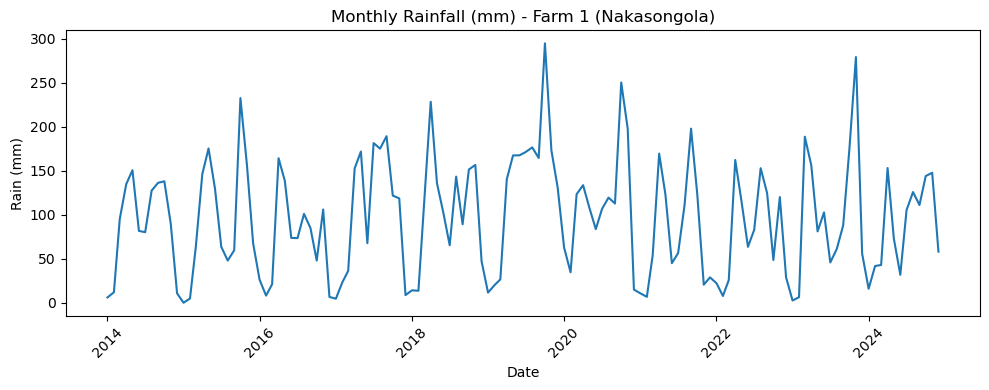

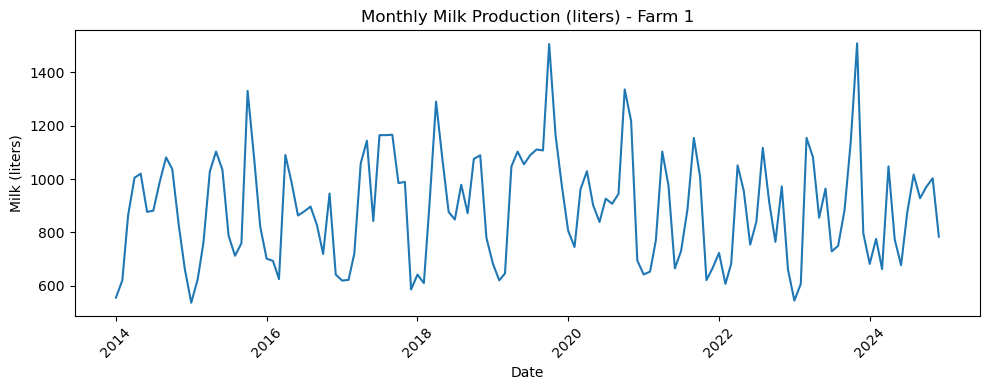

[PLOT] Two time-series plots displayed (rainfall and milk).
[NOTE] These plots are for visual analysis in your report.


In [43]:
# Simple matplotlib plots

print("[PLOT] Creating basic plots for the report...")

# Restrict to one farm for clarity
farm1 = panel_df[panel_df["farm_id"] == 1].copy()
farm1_sorted = farm1.sort_values(["year", "month"])

# Build a time index for plotting
farm1_sorted["date"] = pd.to_datetime(
    farm1_sorted["year"].astype(str) + "-" + farm1_sorted["month"].astype(str) + "-01"
)

plt.figure(figsize=(10, 4))
plt.plot(farm1_sorted["date"], farm1_sorted["rain_mm_total"])
plt.title("Monthly Rainfall (mm) - Farm 1 (Nakasongola)")
plt.xlabel("Date")
plt.ylabel("Rain (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(farm1_sorted["date"], farm1_sorted["milk_liters"])
plt.title("Monthly Milk Production (liters) - Farm 1")
plt.xlabel("Date")
plt.ylabel("Milk (liters)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("[PLOT] Two time-series plots displayed (rainfall and milk).")
print("[NOTE] These plots are for visual analysis in your report.")

In [44]:
# Simple console UI (menu-based)

class ConsoleApp:
    """
    Simple console UI:
    1. Build dataset (2014–2024)
    2. Train & evaluate models
    3. Exit
    """

    def __init__(self, config: ProjectConfig):
        self.config = config
        self.scraper = ClimateScraper(config)
        self.monthly_df: pd.DataFrame | None = None
        self.panel_df: pd.DataFrame | None = None

    def build_data(self):
        print("[APP] Building data (scrape + synthetic)...")
        daily = self.scraper.fetch_daily_data()
        self.monthly_df = self.scraper.to_monthly_panel(daily)
        ds = DataSource(self.config, self.monthly_df)
        self.panel_df = ds.build_panel(n_farms=5)
        print("[APP] Data build complete.")

    def train_and_evaluate(self):
        if self.panel_df is None:
            print("[APP] No data built yet. Choose option 1 first.")
            return

        fb = FeatureBuilder()
        X, y = fb.prepare(self.panel_df)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42
        )

        log_model = LogisticRiskModel()
        rf_model = RandomForestRiskModel()

        log_model.train(X_train, y_train)
        log_model.evaluate(X_test, y_test)

        rf_model.train(X_train, y_train)
        rf_model.evaluate(X_test, y_test)

    def run(self):
        while True:
            print("\n=== Dairy Investment Derisking App ===")
            print("1. Scrape climate & build dataset (2014–2024)")
            print("2. Train & evaluate models")
            print("3. Exit")
            choice = input("Enter choice (1/2/3): ").strip()

            if choice == "1":
                self.build_data()
            elif choice == "2":
                self.train_and_evaluate()
            elif choice == "3":
                print("[APP] Exiting. Goodbye.")
                break
            else:
                print("[APP] Invalid choice. Try again.")

print("[CONFIRM] ConsoleApp class defined.")
print("[NOTE] To run the menu UI, call: app = ConsoleApp(config); app.run()")

[CONFIRM] ConsoleApp class defined.
[NOTE] To run the menu UI, call: app = ConsoleApp(config); app.run()


In [45]:
# Saving dataset
panel_df.to_csv("nakasongola_dairy_panel_2014_2024_synthetic.csv", index=False)

print("[SAVE] Dataset saved as nakasongola_dairy_panel_2014_2024_synthetic.csv")
print("[NOTE] This cell does NOT print dataset rows, only confirms saving.")

[SAVE] Dataset saved as nakasongola_dairy_panel_2014_2024_synthetic.csv
[NOTE] This cell does NOT print dataset rows, only confirms saving.


In [47]:
# pip install fastapi uvicorn pydantic joblib streamlit shap
!pip install fastapi uvicorn pydantic joblib streamlit shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 2.4 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [48]:
# pipeline.py

import os
import joblib

class DeriskingPipeline:
    """
    End-to-end training pipeline:
    - Builds dataset (2014–2024, Nakasongola)
    - Builds features
    - Trains Logistic & RF baselines
    - Picks best model and saves artifacts
    """

    def __init__(self, config: ProjectConfig):
        self.config = config
        self.best_model = None
        self.best_model_name = None
        self.feature_names = None
        print("[PIPELINE] Initialised with config:", self.config)

    def build_data(self) -> pd.DataFrame:
        print("[PIPELINE] Building dataset (scrape + synthetic)...")
        scraper = ClimateScraper(self.config)
        daily_df = scraper.fetch_daily_data()
        monthly_df = scraper.to_monthly_panel(daily_df)

        ds = DataSource(self.config, monthly_df)
        panel_df = ds.build_panel(n_farms=5)

        print("[PIPELINE] Dataset built. Shape:", panel_df.shape)
        return panel_df

    def build_features(self, panel_df: pd.DataFrame):
        print("[PIPELINE] Building features (X, y)...")
        fb = FeatureBuilder()
        X, y = fb.prepare(panel_df)
        self.feature_names = fb.features
        return X, y

    def train_models(self, X, y):
        print("[PIPELINE] Train-test split...")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42
        )
        print("[PIPELINE] Train size:", X_train.shape, "Test size:", X_test.shape)

        log_model = LogisticRiskModel()
        rf_model = RandomForestRiskModel()

        print("[PIPELINE] Training Logistic Regression...")
        log_model.train(X_train, y_train)
        log_proba, _ = log_model.evaluate(X_test, y_test)
        log_auc = roc_auc_score(y_test, log_proba)

        print("[PIPELINE] Training Random Forest...")
        rf_model.train(X_train, y_train)
        rf_proba, _ = rf_model.evaluate(X_test, y_test)
        rf_auc = roc_auc_score(y_test, rf_proba)

        print(f"[PIPELINE] Logistic AUC = {log_auc:.3f}, RF AUC = {rf_auc:.3f}")

        if rf_auc >= log_auc:
            self.best_model = rf_model.model
            self.best_model_name = "RandomForest"
        else:
            self.best_model = log_model.model
            self.best_model_name = "LogisticRegression"

        print(f"[PIPELINE] Best model selected: {self.best_model_name}")

    def save_artifacts(self, artifact_dir: str = "artifacts"):
        os.makedirs(artifact_dir, exist_ok=True)
        model_path = os.path.join(artifact_dir, "best_model.pkl")
        features_path = os.path.join(artifact_dir, "feature_names.pkl")

        joblib.dump(self.best_model, model_path)
        joblib.dump(self.feature_names, features_path)

        print(f"[SAVE] Best model saved to {model_path}")
        print(f"[SAVE] Feature names saved to {features_path}")
        print("[NOTE] These files are used later by the API and Streamlit dashboard.")

    def run(self):
        print("[PIPELINE] Starting full training pipeline...")
        panel_df = self.build_data()
        X, y = self.build_features(panel_df)
        self.train_models(X, y)
        self.save_artifacts()
        print("[PIPELINE] Training pipeline complete.")
        return panel_df

In [49]:
# prints progress and saves artifacts
config = ProjectConfig()
pipeline = DeriskingPipeline(config)
panel_df = pipeline.run()  

[PIPELINE] Initialised with config: ProjectConfig(latitude=1.32, longitude=32.45, start_date='2014-01-01', end_date='2024-12-31')
[PIPELINE] Starting full training pipeline...
[PIPELINE] Building dataset (scrape + synthetic)...
[INIT] ClimateScraper ready with config: ProjectConfig(latitude=1.32, longitude=32.45, start_date='2014-01-01', end_date='2024-12-31')
[STEP] Requesting daily climate data from Open-Meteo...
[OUTPUT] Daily climate data fetched. Shape: (4018, 3)
        date  temp_c_mean  rain_mm
0 2014-01-01         22.6      5.0
1 2014-01-02         23.3      0.1
2 2014-01-03         23.9      0.0
3 2014-01-04         24.1      0.0
4 2014-01-05         24.5      0.0
[STEP] Aggregating daily → monthly climate data...
[OUTPUT] Monthly climate panel ready. Shape: (132, 4)
   year  month  temp_c_mean  rain_mm_total
0  2014      1    24.990323            6.0
1  2014      2    26.128571           11.9
2  2014      3    24.970968           95.0
3  2014      4    22.943333          134

C:\Users\HP\AppData\Local\Temp\ipykernel_19788\2850533434.py:70: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="bfill")
C:\Users\HP\AppData\Local\Temp\ipykernel_19788\2850533434.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method="ffill")
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[OK] Logistic Regression trained.
[STEP] Evaluating Logistic Regression...

=== LOGISTIC REGRESSION METRICS ===
ROC-AUC: 0.8951724137931035
F1-score: 0.4117647058823529
Confusion Matrix:
 [[138   7]
 [ 13   7]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       145
           1       0.50      0.35      0.41        20

    accuracy                           0.88       165
   macro avg       0.71      0.65      0.67       165
weighted avg       0.86      0.88      0.87       165

[PIPELINE] Training Random Forest...
[STEP] Training Random Forest...
[OK] Random Forest trained.
[STEP] Evaluating Random Forest...

=== RANDOM FOREST METRICS ===
ROC-AUC: 1.0
F1-score: 0.9473684210526315
Confusion Matrix:
 [[145   0]
 [  2  18]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       145
           1       1.00      0.90      0.95        20

  

In [50]:
# schemas.py

from pydantic import BaseModel, Field, confloat, conint
from typing import List

class InvestmentRequest(BaseModel):
    """Input schema for /predict endpoint (single farm-month)."""
    temp_c_mean: float = Field(..., description="Monthly mean temperature in °C")
    rain_mm_total: confloat(ge=0) = Field(..., description="Total monthly rainfall (mm)")
    ndvi: confloat(ge=0, le=1) = Field(..., description="NDVI index 0–1")
    milk_liters: confloat(ge=0) = Field(..., description="Monthly milk production (liters)")
    feed_cost_ugx: confloat(ge=0) = Field(..., description="Monthly feed cost in UGX")
    vet_visits: conint(ge=0) = Field(..., description="Number of vet visits this month")
    loan_access: conint(ge=0, le=1) = Field(..., description="1 if farm has loan access, else 0")
    outages_days: conint(ge=0) = Field(..., description="Number of outage days this month")
    market_price_ugx_per_liter: confloat(ge=0) = Field(..., description="Farm-gate price per litre (UGX)")


class InvestmentResponse(BaseModel):
    """Output schema for /predict."""
    investment_feasible: int
    probability: float
    model_used: str
    top_features: List[str]
    message: str

In [57]:
%%writefile schemas.py
from pydantic import BaseModel, Field, confloat, conint
from typing import List

class InvestmentRequest(BaseModel):
    temp_c_mean: float
    rain_mm_total: confloat(ge=0)
    ndvi: confloat(ge=0, le=1)
    milk_liters: confloat(ge=0)
    feed_cost_ugx: confloat(ge=0)
    vet_visits: conint(ge=0)
    loan_access: conint(ge=0, le=1)
    outages_days: conint(ge=0)
    market_price_ugx_per_liter: confloat(ge=0)

class InvestmentResponse(BaseModel):
    investment_feasible: int
    probability: float
    model_used: str
    top_features: List[str]
    message: str

Writing schemas.py


In [59]:
from schemas import InvestmentRequest, InvestmentResponse
print("Schemas imported!")

Schemas imported!


In [61]:
# pip install fastapi uvicorn pydantic joblib scikit-learn pandas numpy matplotlib requests
!pip install fastapi uvicorn pydantic joblib scikit-learn pandas numpy matplotlib requests


In [63]:
%%writefile api_server.py
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
import pandas as pd
import joblib
import numpy as np

from schemas import InvestmentRequest, InvestmentResponse

app = FastAPI(title="Nakasongola Dairy Derisking API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

MODEL_PATH = "artifacts/best_model.pkl"
FEATURES_PATH = "artifacts/feature_names.pkl"

model = None
feature_names = None
model_name = None

@app.on_event("startup")
def load_artifacts():
    global model, feature_names, model_name
    print("[API] Loading model and feature names...")
    model = joblib.load(MODEL_PATH)
    feature_names = joblib.load(FEATURES_PATH)
    model_name = model.__class__.__name__
    print(f"[API] Loaded model: {model_name}")
    print(f"[API] Feature order: {feature_names}")

@app.post("/predict", response_model=InvestmentResponse)
def predict_investment(request: InvestmentRequest):
    print("[API] Received request:", request.dict())

    x_dict = {
        "temp_c_mean": request.temp_c_mean,
        "rain_mm_total": request.rain_mm_total,
        "ndvi": request.ndvi,
        "milk_liters": request.milk_liters,
        "feed_cost_ugx": request.feed_cost_ugx,
        "vet_visits": request.vet_visits,
        "loan_access": request.loan_access,
        "outages_days": request.outages_days,
        "market_price_ugx_per_liter": request.market_price_ugx_per_liter,
    }
    X = pd.DataFrame([x_dict])[feature_names]

    proba = float(model.predict_proba(X)[:, 1][0])
    label = int(proba >= 0.5)

    # Simple feature importance ranking
    top_features = []
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        sorted_idx = np.argsort(importances)[::-1]
        top_features = [feature_names[i] for i in sorted_idx[:3]]
    elif hasattr(model, "coef_"):
        coef = model.coef_[0]
        sorted_idx = np.argsort(np.abs(coef))[::-1]
        top_features = [feature_names[i] for i in sorted_idx[:3]]

    msg = "Investment appears feasible." if label == 1 else "Investment appears risky."

    print(f"[API] Prediction → label={label}, proba={proba:.3f}, top_features={top_features}")

    return InvestmentResponse(
        investment_feasible=label,
        probability=proba,
        model_used=model_name,
        top_features=top_features,
        message=msg,
    )

Writing api_server.py


In [65]:
{
  "temp_c_mean": 24.5,
  "rain_mm_total": 160,
  "ndvi": 0.6,
  "milk_liters": 800,
  "feed_cost_ugx": 210000,
  "vet_visits": 1,
  "loan_access": 1,
  "outages_days": 2,
  "market_price_ugx_per_liter": 1500
}


{'temp_c_mean': 24.5,
 'rain_mm_total': 160,
 'ndvi': 0.6,
 'milk_liters': 800,
 'feed_cost_ugx': 210000,
 'vet_visits': 1,
 'loan_access': 1,
 'outages_days': 2,
 'market_price_ugx_per_liter': 1500}

In [67]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is C6E9-1E28

 Directory of C:\Users\HP\OOP UCU\OOP\Nakasongola Cattle Project

06/12/2025  12:10    <DIR>          .
05/12/2025  23:28    <DIR>          ..
06/12/2025  12:05    <DIR>          .ipynb_checkpoints
06/12/2025  10:03    <DIR>          .vscode
06/12/2025  11:58             2,515 api_server.py
06/12/2025  11:34    <DIR>          artifacts
06/12/2025  12:10           227,617 Desrisking Project Nakasongola.ipynb
06/12/2025  10:58            77,032 nakasongola_dairy_panel_2014_2024_synthetic.csv
06/12/2025  11:40               589 schemas.py
06/12/2025  11:41    <DIR>          __pycache__
               4 File(s)        307,753 bytes
               6 Dir(s)  420,151,660,544 bytes free


In [ ]:
http://127.0.0.1:8001/docs#/default/predict_investment_predict_post